# Frequencia_Cor v1 — Treinamento
FFT + Cor RGB/HSV + Estatísticas PCA Invariantes + XGBoost

**Features (35 dims):** PCA invariante (6) | PCA escalar (6) | RGB (12) | HSV (6) | FFT (5)

---
## Setup

In [107]:
import random
import warnings
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from io import BytesIO
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

from PIL import Image, ImageFile, ImageFilter, ImageEnhance
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings('ignore', message='.*decompression bomb.*', category=UserWarning)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, brier_score_loss
)

from xgboost import XGBClassifier

In [108]:
# detecta a raiz do projeto pelo .git, independente de onde o notebook foi aberto
_here = Path('.').resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / '.git').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / 'modelos' / 'Frequencia_Cor'
CACHE_DIR  = PROJECT_ROOT / 'cache_freq_cor_v1'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_REAL = Path(r'D:\TCCDataset\train\real')
TRAIN_FAKE = Path(r'D:\TCCDataset\train\fake')
TEST_REAL  = Path(r'D:\TCCDataset\test\real')
TEST_FAKE  = Path(r'D:\TCCDataset\test\fake')

EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
RESIZE_TO   = (256, 256)   # padronizado com luminância e ruído
N_PCA_COMP  = 30
RANDOM_SEED = 42

print(f'output : {OUTPUT_DIR}')
print(f'cache  : {CACHE_DIR}')
print(f'resize : {RESIZE_TO}')

output : C:\Users\user\Desktop\TCC\Xiz9\modelos\Frequencia_Cor
cache  : C:\Users\user\Desktop\TCC\Xiz9\cache_freq_cor_v1
resize : (256, 256)


---
## Funções de extração

In [109]:
def _pca_distribution_features(eig: np.ndarray) -> list:
    # estatísticas invariantes à base — comparáveis entre imagens independentemente da direção dos componentes
    eig_sorted = np.sort(eig)[::-1]
    norm_eig   = eig_sorted / (eig_sorted.sum() + 1e-12)

    eigen_entropy = float(-np.sum(norm_eig * np.log(norm_eig + 1e-12)))
    top5_ratio    = float(eig_sorted[:5].sum() / (eig_sorted[-5:].sum() + 1e-12))

    cumsum = np.cumsum(norm_eig)
    n_50   = int(np.searchsorted(cumsum, 0.50) + 1)
    n_90   = int(np.searchsorted(cumsum, 0.90) + 1)
    n_95   = int(np.searchsorted(cumsum, 0.95) + 1)

    k     = np.arange(1, len(eig_sorted) + 1)
    slope = float(np.polyfit(np.log(k), np.log(eig_sorted + 1e-12), 1)[0])

    return [eigen_entropy, top5_ratio, n_50, n_90, n_95, slope]

In [110]:
def augment_image_bytes(image_bytes: bytes) -> bytes:
    img = Image.open(BytesIO(image_bytes)).convert('RGB')

    if random.random() < 0.5:
        scale = random.uniform(0.75, 1.25)
        img = img.resize((int(img.width * scale), int(img.height * scale)), Image.LANCZOS)

    if random.random() < 0.7:
        quality = random.randint(60, 95)
        buf = BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        img = Image.open(BytesIO(buf.getvalue())).convert('RGB')

    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))

    if random.random() < 0.3:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.15))

    out = BytesIO()
    img.save(out, format='PNG')
    return out.getvalue()

In [111]:
def _reconstruction_error(matrix, pca, scores, k):
    sk = np.zeros_like(scores)
    sk[:, :k] = scores[:, :k]
    return float(np.mean((matrix - pca.inverse_transform(sk)) ** 2))


def extract_freq_cor_features(image_bytes: bytes) -> np.ndarray | None:
    try:
        img_rgb  = Image.open(BytesIO(image_bytes)).convert('RGB').resize(RESIZE_TO)
        img_gray = img_rgb.convert('L')
        arr_rgb  = np.array(img_rgb,  dtype=np.float64) / 255.0
        arr_gray = np.array(img_gray, dtype=np.float64) / 255.0

        # PCA no canal cinza
        n      = min(N_PCA_COMP, min(arr_gray.shape))
        pca    = PCA(n_components=n, svd_solver='randomized', random_state=RANDOM_SEED)
        scores = pca.fit_transform(arr_gray)
        eig    = pca.explained_variance_
        evr    = pca.explained_variance_ratio_

        pca_inv_feats = _pca_distribution_features(eig)

        geo_mean  = float(np.exp(np.mean(np.log(eig + 1e-12))))
        spec_flat = geo_mean / (float(np.mean(eig)) + 1e-12)
        first_dom = float(evr[0])
        coef_var  = float(np.std(eig) / (np.mean(eig) + 1e-12))
        rec_k5    = _reconstruction_error(arr_gray, pca, scores, min(5,  n))
        rec_k10   = _reconstruction_error(arr_gray, pca, scores, min(10, n))
        pca_scalar_feats = [spec_flat, first_dom, coef_var, rec_k5, rec_k10,
                            _reconstruction_error(arr_gray, pca, scores, min(20, n))]

        # Cor RGB
        color_feats = []
        for c in range(3):
            ch = arr_rgb[:, :, c].ravel()
            mu = ch.mean()
            sd = ch.std() + 1e-12
            color_feats += [float(mu), float(sd),
                            float(np.mean(((ch - mu) / sd) ** 3)),
                            float(np.mean(((ch - mu) / sd) ** 4))]

        # Cor HSV
        try:
            arr_hsv = np.array(
                Image.open(BytesIO(image_bytes)).convert('RGB').resize(RESIZE_TO).convert('HSV'),
                dtype=np.float64
            ) / 255.0
            hsv_feats = []
            for c in range(3):
                ch = arr_hsv[:, :, c].ravel()
                hsv_feats += [float(np.mean(ch)), float(np.std(ch))]
        except Exception:
            hsv_feats = [0.0] * 6

        # FFT — fftshift desloca o DC para o centro, permitindo bandas radiais
        fft     = np.fft.fft2(arr_gray)
        fft_mag = np.abs(np.fft.fftshift(fft))

        h, w     = fft_mag.shape
        cy, cx   = h // 2, w // 2
        Y, X     = np.ogrid[:h, :w]
        dist     = np.sqrt((X - cx)**2 + (Y - cy)**2)
        max_dist = np.sqrt(cx**2 + cy**2)

        e_low   = float(np.sum(fft_mag[dist <= max_dist * 0.1] ** 2))
        e_mid   = float(np.sum(fft_mag[(dist > max_dist * 0.1) & (dist <= max_dist * 0.4)] ** 2))
        e_high  = float(np.sum(fft_mag[dist > max_dist * 0.4] ** 2))
        e_total = e_low + e_mid + e_high + 1e-12

        fft_feats = [
            e_low  / e_total,
            e_mid  / e_total,
            e_high / e_total,
            e_high / (e_low + 1e-12),
            float(np.std(np.log1p(fft_mag))),
        ]

        result = np.array(pca_inv_feats + pca_scalar_feats + color_feats + hsv_feats + fft_feats,
                          dtype=np.float32)
        return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

    except Exception:
        return None


# teste rápido
sample_files = [f for f in TRAIN_REAL.rglob('*') if f.suffix.lower() in EXTENSIONS]
assert len(sample_files) > 0, f'nenhuma imagem em {TRAIN_REAL}'
sample = extract_freq_cor_features(sample_files[0].read_bytes())
print(f'features: {len(sample)} dims | NaN: {np.isnan(sample).sum()} | Inf: {np.isinf(sample).sum()}')

features: 35 dims | NaN: 0 | Inf: 0


---
## Extração do dataset

In [112]:
def list_images(folder: Path) -> list:
    return [p for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]


def _process_one(args):
    fpath, label, do_augment = args
    results = []
    try:
        raw  = fpath.read_bytes()
        feat = extract_freq_cor_features(raw)
        if feat is not None:
            results.append((feat, label))
        if do_augment:
            feat_aug = extract_freq_cor_features(augment_image_bytes(raw))
            if feat_aug is not None:
                results.append((feat_aug, label))
    except Exception:
        pass
    return results


def extract_split(real_folder, fake_folder, prefix, augment=False, n_workers=8):
    cache_X = CACHE_DIR / f'{prefix}_X.npy'
    cache_y = CACHE_DIR / f'{prefix}_y.npy'

    if cache_X.exists() and cache_y.exists():
        print(f'{prefix}: carregando do cache')
        return np.load(cache_X), np.load(cache_y)

    files = ([(f, 0, augment) for f in list_images(real_folder)] +
             [(f, 1, augment) for f in list_images(fake_folder)])

    print(f'{prefix}: {len(files)} imagens', '(+aug)' if augment else '')

    X, y = [], []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for results in tqdm(executor.map(_process_one, files), total=len(files), desc=prefix):
            for feat, label in results:
                X.append(feat)
                y.append(label)

    X_arr = np.array(X, dtype=np.float32)
    y_arr = np.array(y, dtype=np.int8)
    np.save(cache_X, X_arr)
    np.save(cache_y, y_arr)
    return X_arr, y_arr


X_train_full, y_train_full = extract_split(TRAIN_REAL, TRAIN_FAKE, 'train', augment=True)
X_test,       y_test       = extract_split(TEST_REAL,  TEST_FAKE,  'test',  augment=False)

print(f'train: {X_train_full.shape} | test: {X_test.shape}')

train: 48000 imagens (+aug)


train:  61%|██████    | 29262/48000 [4:45:24<38:48,  8.05it/s]   c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
train:  70%|██████▉   | 33385/48000 [5:00:56<46:24,  5.25it/s]  c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
train:  70%|██████▉   | 33390/48000 [5:00:56<37:52,  6.43it/s]c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site

test: 12000 imagens 


test:  58%|█████▊    | 6949/12000 [15:36<05:55, 14.22it/s]  c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
test:  58%|█████▊    | 6954/12000 [15:37<06:32, 12.85it/s]c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
test:  63%|██████▎   | 7557/12000 [16:22<10:25,  7.10it/s]c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
test:  63%|██████▎   | 7573/12000 [16:23<04:38, 15.91it/s]c:

train: (96000, 35) | test: (12000, 35)


---
## Treino / Validação / Teste

In [113]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_SEED
)

print(f'treino: {X_tr.shape[0]} | val: {X_val.shape[0]} | teste: {X_test.shape[0]}')

treino: 76800 | val: 19200 | teste: 12000


---
## Normalização

In [114]:
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

---
## XGBoost

In [115]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_model = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = RANDOM_SEED,
    n_jobs                = -1,
    verbosity             = 0,
)

xgb_model.fit(
    X_tr_s, y_tr,
    eval_set=[(X_val_s, y_val)],
    verbose=50
)

[0]	validation_0-auc:0.74731
[50]	validation_0-auc:0.80294
[100]	validation_0-auc:0.82380
[150]	validation_0-auc:0.83786
[200]	validation_0-auc:0.84836
[250]	validation_0-auc:0.85601
[300]	validation_0-auc:0.86298
[350]	validation_0-auc:0.86854
[400]	validation_0-auc:0.87350
[450]	validation_0-auc:0.87798
[499]	validation_0-auc:0.88203


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

---
## Comparação de Classificadores

In [116]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

scale_pw = (y_tr == 0).sum() / (y_tr == 1).sum()

OUTROS_CLASSIFICADORES = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000,
        solver='lbfgs', random_state=RANDOM_SEED, n_jobs=-1),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        max_iter=300, early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_SEED),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, learning_rate=0.1, random_state=RANDOM_SEED),
    'KNN (k=7)': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=RANDOM_SEED),
    'Naive Bayes': GaussianNB(),
    # 'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale',
    #     class_weight='balanced', probability=True, random_state=RANDOM_SEED),
}

# XGBoost já treinado — só avaliar
resultados = [{
    'nome': 'XGBoost', 'clf': xgb_model,
    'y_pred':  xgb_model.predict(X_test_s),
    'y_proba': xgb_model.predict_proba(X_test_s)[:, 1],
    'accuracy': accuracy_score(y_test, xgb_model.predict(X_test_s)),
    'f1':       f1_score(y_test,       xgb_model.predict(X_test_s)),
    'auc':      roc_auc_score(y_test,  xgb_model.predict_proba(X_test_s)[:, 1]),
    'tempo': 0.0,
}]

for nome, clf in OUTROS_CLASSIFICADORES.items():
    print(f'treinando {nome}...')
    t0 = time.time()
    clf.fit(X_tr_s, y_tr)
    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1] if hasattr(clf, 'predict_proba') \
              else clf.decision_function(X_test_s)
    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    auc   = roc_auc_score(y_test, y_proba)
    tempo = time.time() - t0
    resultados.append({'nome': nome, 'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
                        'accuracy': acc, 'f1': f1, 'auc': auc, 'tempo': tempo})
    print(f'   Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | {tempo:.1f}s')

resultados.sort(key=lambda x: x['accuracy'], reverse=True)

# melhor classificador
best_result  = resultados[0]
best_clf      = best_result['clf']
best_clf_nome = best_result['nome']

print(f'\n{"="*60}')
print(f'{"Classificador":<22} {"Acc":>8} {"F1":>8} {"AUC":>8} {"Tempo":>8}')
print(f'{"="*60}')
for r in resultados:
    star = ' ←' if r['nome'] == best_clf_nome else ''
    print(f"{r['nome']:<22} {r['accuracy']:>8.4f} {r['f1']:>8.4f} {r['auc']:>8.4f} {r['tempo']:>7.1f}s{star}")
print(f'{"="*60}')
print(f'\nmelhor: {best_clf_nome}')

treinando Random Forest...
   Acc=0.7523 | F1=0.7618 | AUC=0.8285 | 31.9s
treinando Extra Trees...
   Acc=0.7446 | F1=0.7574 | AUC=0.8179 | 12.8s
treinando Gradient Boosting...
   Acc=0.7492 | F1=0.7599 | AUC=0.8301 | 230.2s
treinando Logistic Regression...


c:\Users\user\Desktop\TCC\Xiz9\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


   Acc=0.7006 | F1=0.7218 | AUC=0.7614 | 1.3s
treinando MLP...
   Acc=0.7491 | F1=0.7439 | AUC=0.8245 | 114.0s
treinando AdaBoost...
   Acc=0.6766 | F1=0.7167 | AUC=0.7350 | 71.3s
treinando KNN (k=7)...
   Acc=0.7040 | F1=0.7185 | AUC=0.7708 | 4.9s
treinando Decision Tree...
   Acc=0.7017 | F1=0.7215 | AUC=0.7566 | 2.9s
treinando Naive Bayes...
   Acc=0.5695 | F1=0.6936 | AUC=0.6827 | 0.0s

Classificador               Acc       F1      AUC    Tempo
XGBoost                  0.7664   0.7747   0.8476     0.0s ←
Random Forest            0.7523   0.7618   0.8285    31.9s
Gradient Boosting        0.7492   0.7599   0.8301   230.2s
MLP                      0.7491   0.7439   0.8245   114.0s
Extra Trees              0.7446   0.7574   0.8179    12.8s
KNN (k=7)                0.7040   0.7185   0.7708     4.9s
Decision Tree            0.7017   0.7215   0.7566     2.9s
Logistic Regression      0.7006   0.7218   0.7614     1.3s
AdaBoost                 0.6766   0.7167   0.7350    71.3s
Naive Bayes   

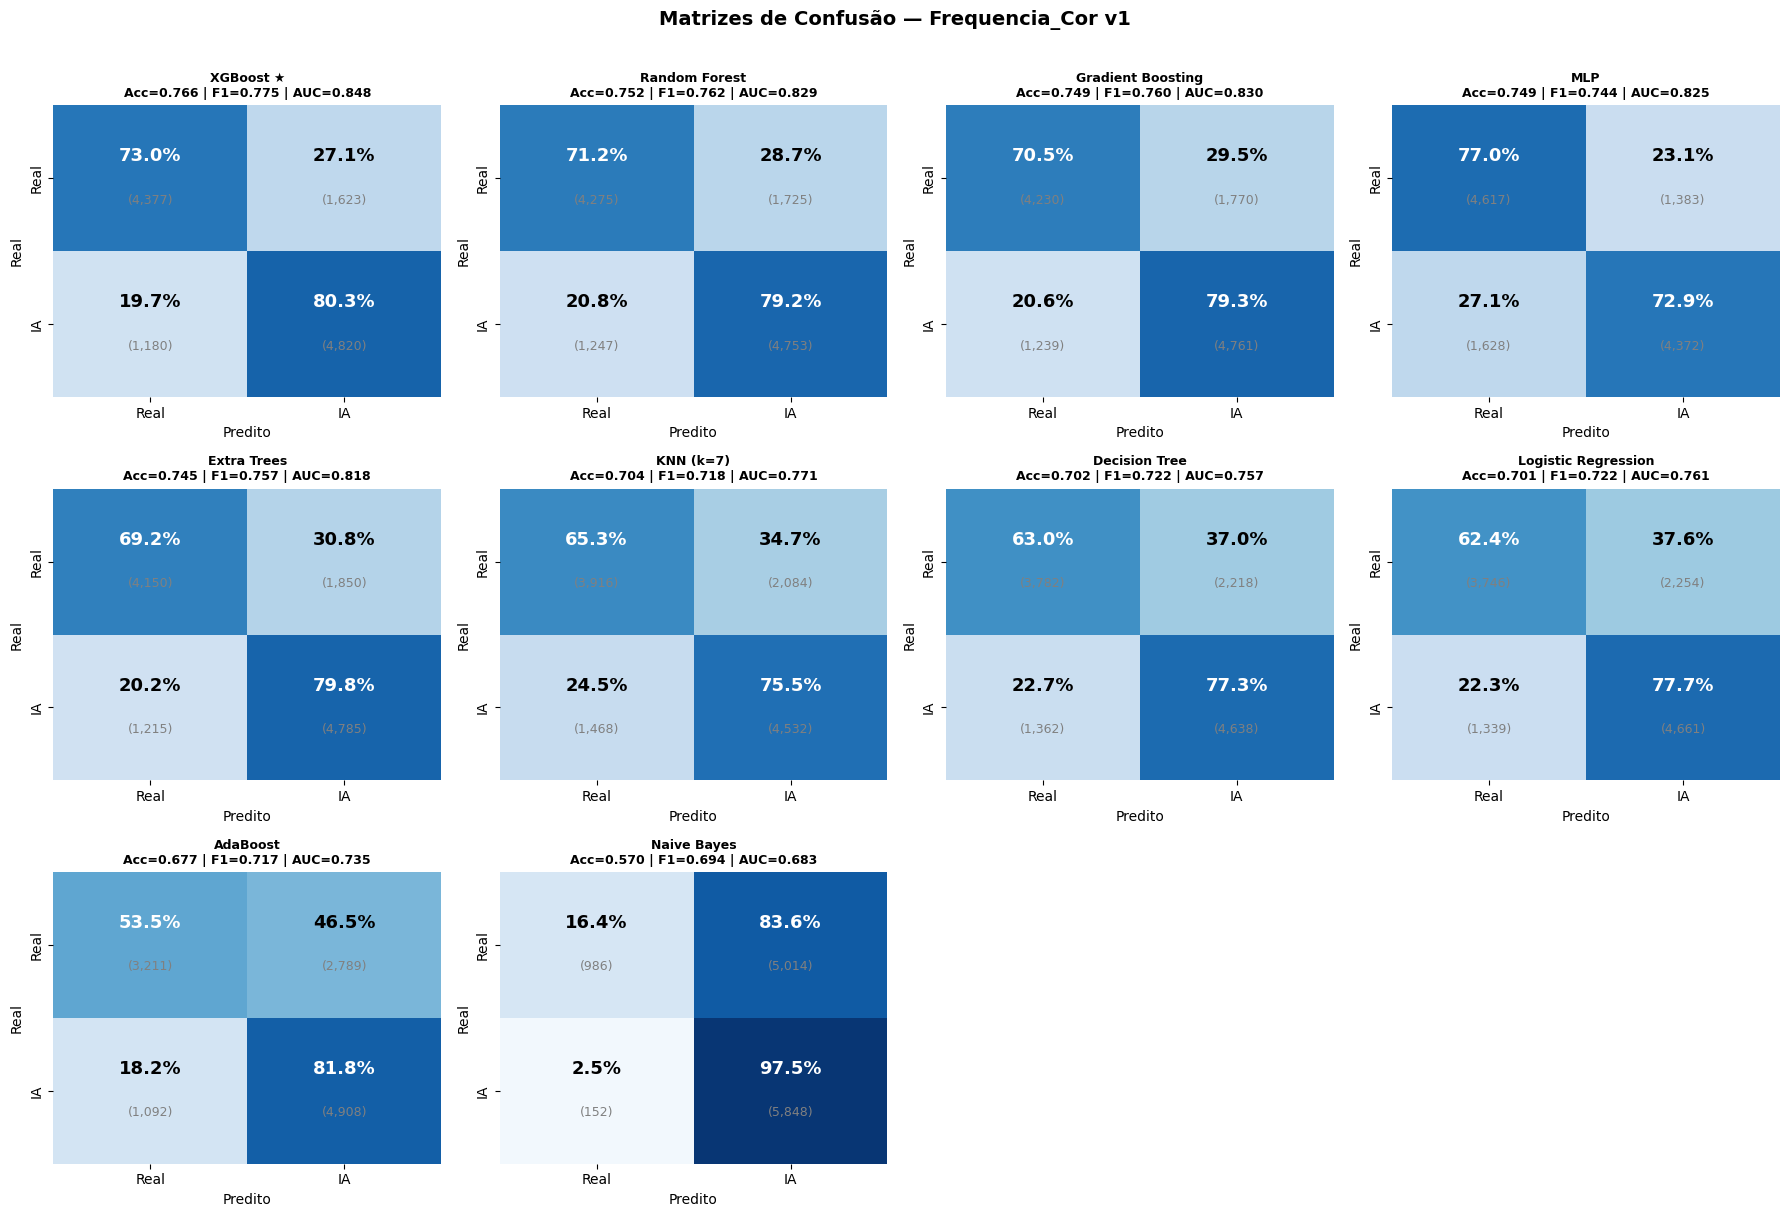

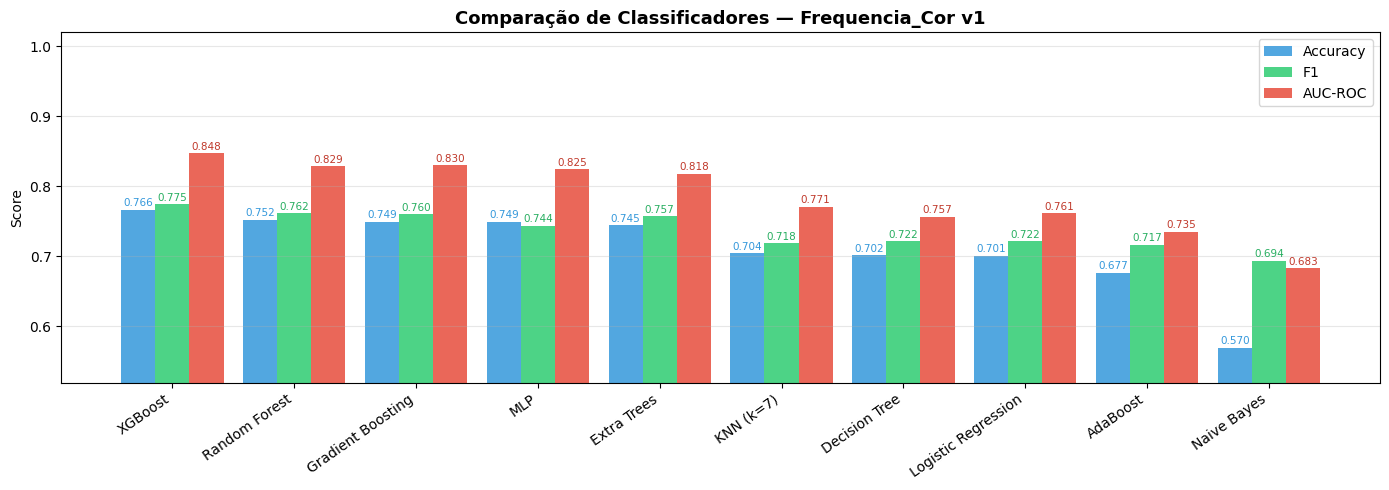

In [117]:
# matrizes de confusão — todos os classificadores
n_clf = len(resultados)
cols  = 4
rows  = (n_clf + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes_flat = axes.flatten()

for idx, r in enumerate(resultados):
    ax     = axes_flat[idx]
    cm     = confusion_matrix(y_test, r['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=False, cmap='Blues', ax=ax,
                xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
                vmin=0, vmax=100, cbar=False)
    for i in range(2):
        for j in range(2):
            cor = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j+0.5, i+0.35, f'{cm_pct[i,j]:.1f}%',
                    ha='center', va='center', fontsize=13, fontweight='bold', color=cor)
            ax.text(j+0.5, i+0.65, f'({cm[i,j]:,})',
                    ha='center', va='center', fontsize=9, color='gray')
    star = ' ★' if r['nome'] == best_clf_nome else ''
    ax.set_title(f"{r['nome']}{star}\nAcc={r['accuracy']:.3f} | F1={r['f1']:.3f} | AUC={r['auc']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predito')

for idx in range(n_clf, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrizes de Confusão — Frequencia_Cor v1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'comparacao_matrizes_confusao.png', dpi=120, bbox_inches='tight')
plt.show()

# ranking
nomes = [r['nome'] for r in resultados]
accs  = [r['accuracy'] for r in resultados]
f1s   = [r['f1']       for r in resultados]
aucs  = [r['auc']      for r in resultados]

x = np.arange(len(nomes)); w = 0.28
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - w, accs, w, label='Accuracy', color='#3498db', alpha=0.85)
b2 = ax.bar(x,     f1s,  w, label='F1',       color='#2ecc71', alpha=0.85)
b3 = ax.bar(x + w, aucs, w, label='AUC-ROC',  color='#e74c3c', alpha=0.85)
for bars, cor in [(b1,'#3498db'),(b2,'#27ae60'),(b3,'#c0392b')]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color=cor)
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=35, ha='right', fontsize=10)
ax.set_ylim(min(min(accs),min(f1s),min(aucs))-0.05, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de Classificadores — Frequencia_Cor v1', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'comparacao_ranking.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Calibração e limiar ótimo

In [118]:
from sklearn.isotonic import IsotonicRegression

print(f'calibrando probabilidades do melhor classificador ({best_clf_nome})...')

# probabilidades brutas — val e test
proba_val_raw  = best_clf.predict_proba(X_val_s)[:, 1]
proba_test_raw = best_clf.predict_proba(X_test_s)[:, 1]

# calibração isotônica no val
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(proba_val_raw, y_val)

# aplicar calibração no test
proba_test_cal = calibrator.predict(proba_test_raw)
brier_antes  = brier_score_loss(y_test, proba_test_raw)
brier_depois = brier_score_loss(y_test, proba_test_cal)
print(f'   Brier antes : {brier_antes:.4f}')
print(f'   Brier depois: {brier_depois:.4f} ({"melhorou" if brier_depois < brier_antes else "piorou"})')

# limiar ótimo por F1 no val
proba_val_cal         = calibrator.predict(proba_val_raw)
prec, rec, thresholds = precision_recall_curve(y_val, proba_val_cal)
f1_scores             = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_idx              = int(np.argmax(f1_scores))
best_thr              = float(thresholds[best_idx])

print(f'\n   Limiar padrão (0.50): F1 = {f1_score(y_test, (proba_test_cal >= 0.50).astype(int)):.4f}')
print(f'   Limiar ótimo  ({best_thr:.2f}): F1 = {f1_score(y_test, (proba_test_cal >= best_thr).astype(int)):.4f}')

y_pred_final = (proba_test_cal >= best_thr).astype(int)

calibrando probabilidades do melhor classificador (XGBoost)...
   Brier antes : 0.1592
   Brier depois: 0.1602 (piorou)

   Limiar padrão (0.50): F1 = 0.7709
   Limiar ótimo  (0.44): F1 = 0.7810


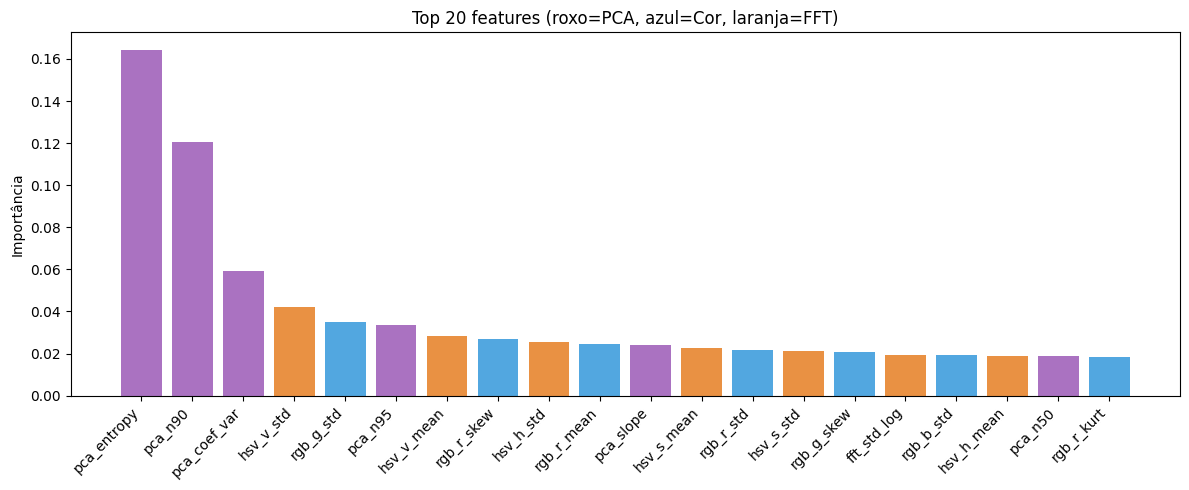

In [119]:
feature_names = (
    ['pca_entropy', 'pca_top5_ratio', 'pca_n50', 'pca_n90', 'pca_n95', 'pca_slope'] +
    ['pca_spec_flat', 'pca_first_dom', 'pca_coef_var', 'pca_rec_k5', 'pca_rec_k10', 'pca_rec_k20'] +
    [f'rgb_{ch}_{s}' for ch in ['r','g','b'] for s in ['mean','std','skew','kurt']] +
    [f'hsv_{ch}_{s}' for ch in ['h','s','v'] for s in ['mean','std']] +
    ['fft_low', 'fft_mid', 'fft_high', 'fft_ratio_hl', 'fft_std_log']
)

importances = xgb_model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
colors = ['#9b59b6' if i < 12 else ('#3498db' if i < 24 else '#e67e22') for i in top_idx]
plt.bar(range(20), importances[top_idx], color=colors, alpha=0.85)
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 features (roxo=PCA, azul=Cor, laranja=FFT)')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Salvar modelos

In [120]:
modelo_path     = OUTPUT_DIR / 'modelo_freq_cor_v1.pkl'
scaler_path     = OUTPUT_DIR / 'scaler_freq_cor.pkl'
calibrator_path = OUTPUT_DIR / 'calibrator_freq_cor.pkl'
threshold_path  = OUTPUT_DIR / 'threshold.json'

joblib.dump(best_clf,   modelo_path)
joblib.dump(scaler,     scaler_path)
joblib.dump(calibrator, calibrator_path)

with open(threshold_path, 'w') as f:
    json.dump({'threshold': best_thr, 'classificador': best_clf_nome,
               'f1_val': float(f1_scores[best_idx]), 'auc_test': auc}, f, indent=2)

print(f'salvos em {OUTPUT_DIR}')
print(f'   {modelo_path.name}  ({best_clf_nome})')
print(f'   {scaler_path.name}')
print(f'   {calibrator_path.name}')
print(f'   threshold.json  →  {best_thr:.4f}')

salvos em C:\Users\user\Desktop\TCC\Xiz9\modelos\Frequencia_Cor
   modelo_freq_cor_v1.pkl  (XGBoost)
   scaler_freq_cor.pkl
   calibrator_freq_cor.pkl
   threshold.json  →  0.4351


---
## Relatório Final

In [121]:
acc = accuracy_score(y_test, y_pred_final)
f1  = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, proba_test_cal)
cm  = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

sep = '=' * 55
print(sep)
print(f'  RELATÓRIO FINAL — Frequencia_Cor v1')
print(f'  Classificador : {best_clf_nome}')
print(sep)
print(f'  {"Accuracy":<22}: {acc:.4f}')
print(f'  {"F1 Score":<22}: {f1:.4f}')
print(f'  {"AUC-ROC":<22}: {auc:.4f}')
print(f'  {"Brier (antes cal.)":<22}: {brier_antes:.4f}')
print(f'  {"Brier (depois cal.)":<22}: {brier_depois:.4f}')
print(f'  {"Threshold (F1 ótimo)":<22}: {best_thr:.4f}')
print(sep)
print(f'  {"FP  Real → IA":<22}: {fp:,} ({fp/(tn+fp)*100:.1f}%)')
print(f'  {"FN  IA  → Real":<22}: {fn:,} ({fn/(fn+tp)*100:.1f}%)')
print(f'  {"Zona incerteza 35-65%":<22}: {((proba_test_cal>0.35)&(proba_test_cal<0.65)).mean()*100:.1f}%')
print(sep)
print()
print(classification_report(y_test, y_pred_final, target_names=['Real', 'IA']))

  RELATÓRIO FINAL — Frequencia_Cor v1
  Classificador : XGBoost
  Accuracy              : 0.7602
  F1 Score              : 0.7810
  AUC-ROC               : 0.8475
  Brier (antes cal.)    : 0.1592
  Brier (depois cal.)   : 0.1602
  Threshold (F1 ótimo)  : 0.4351
  FP  Real → IA         : 2,010 (33.5%)
  FN  IA  → Real        : 868 (14.5%)
  Zona incerteza 35-65% : 23.0%

              precision    recall  f1-score   support

        Real       0.82      0.67      0.73      6000
          IA       0.72      0.86      0.78      6000

    accuracy                           0.76     12000
   macro avg       0.77      0.76      0.76     12000
weighted avg       0.77      0.76      0.76     12000



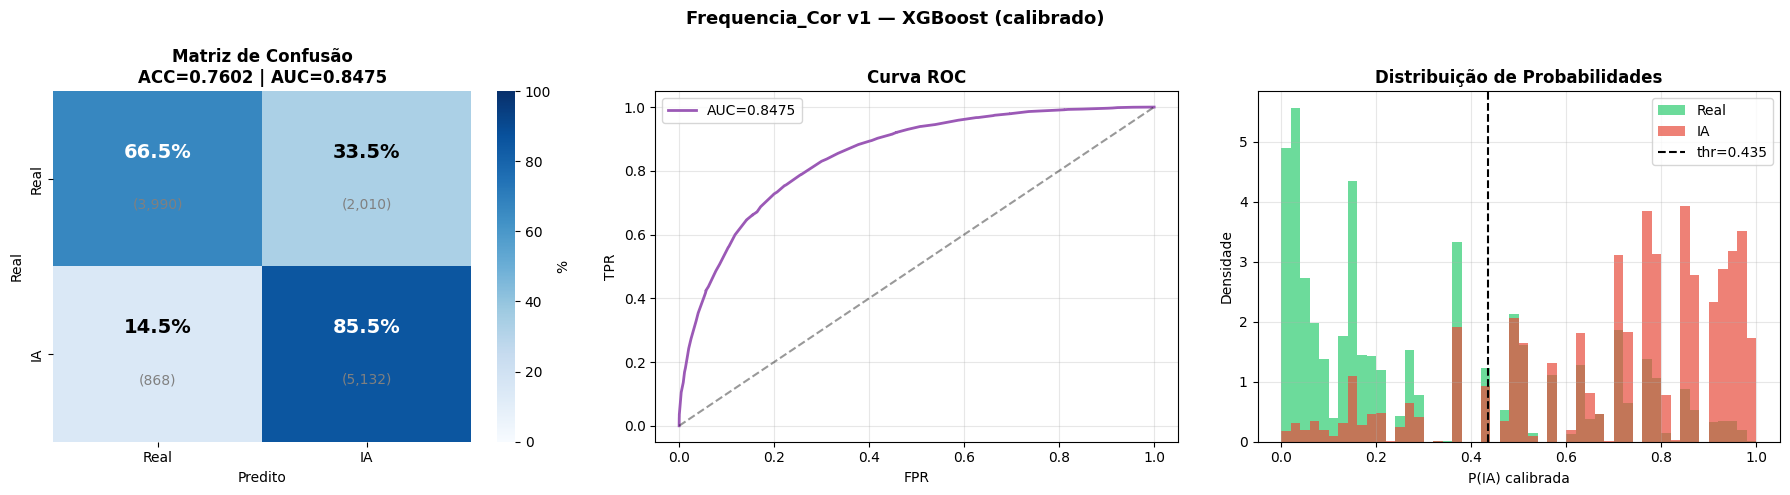

In [122]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=False, cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            vmin=0, vmax=100, cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        cor = 'white' if cm_pct[i, j] > 50 else 'black'
        axes[0].text(j+0.5, i+0.35, f'{cm_pct[i,j]:.1f}%',
                     ha='center', va='center', fontsize=14, fontweight='bold', color=cor)
        axes[0].text(j+0.5, i+0.65, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=10, color='gray')
axes[0].set_title(f'Matriz de Confusão\nACC={acc:.4f} | AUC={auc:.4f}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

fpr, tpr, _ = roc_curve(y_test, proba_test_cal)
axes[1].plot(fpr, tpr, color='#9b59b6', linewidth=2, label=f'AUC={auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(proba_test_cal[y_test==0], bins=50, alpha=0.7, color='#2ecc71', label='Real', density=True)
axes[2].hist(proba_test_cal[y_test==1], bins=50, alpha=0.7, color='#e74c3c', label='IA',   density=True)
axes[2].axvline(best_thr, color='black', linestyle='--', label=f'thr={best_thr:.3f}')
axes[2].set_xlabel('P(IA) calibrada'); axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição de Probabilidades', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'Frequencia_Cor v1 — {best_clf_nome} (calibrado)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'relatorio_final.png', dpi=120, bbox_inches='tight')
plt.show()